In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from dataclasses import dataclass, field, asdict
from typing import List, Dict, Tuple, Optional, Union

import gcsfs
import os
import sys
import json
from pprint import pprint
sys.path.append(os.path.abspath(os.path.join('diffusionsim')))

#fs = gcsfs.GCSFileSystem()
#fs.ls("gs://leap-persistent/sammyagrawal/") # List files in the bucket where the E3SM-MMF dataset is stored

In [2]:
import torch
import torch.nn as nn
import xbatcher
import torch.nn.functional as F

import diffusers
import diffusionsim as diff
import diffusionsim.training_utils as tru
from diffusionsim import mydatasets as data
import diffusionsim.evaluations as evals

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

# Playground

In [5]:
dconfig = tru.my_dconfig("local-vzarr", "v1", in_notebook=True, shuffle_indices=False, 
                        dataset_type="climsim", batch_size=64, use_tendencies=True)
dconfig.train_test_split = [1.0]
pprint(dconfig)

DataConfig(dataset_type='climsim',
           climsim_type='low-res-expanded',
           source='local-vzarr',
           data_dir='/mnt/home/ssa2206/Climsim/diffusion-climsim/data/local_manifests',
           train_test_split=[1.0],
           dataloader_params=DataLoaderParams(batch_size=24576,
                                              shuffle=True,
                                              num_workers=0,
                                              prefetch_factor=None,
                                              persistent_workers=False,
                                              multiprocessing_context=None,
                                              pin_memory=True),
           data_vars='v1',
           use_tendencies=True,
           norm_info='image',
           chunksize={},
           log_batching=True,
           shuffle_indices=False)


In [ ]:
REF_BATCH_SIZE = 128
def setup_diffusion_run(num_models, exp_id, base_run_id, data_vars='v1', batch_size=128):
    
    tconfigs, mconfigs = [], []

    learning_rates = [1e-5, 1e-5, 1e-5, 1e-5, 1e-5]
    unet_layers_per_block = [1, 1, 2, 2, 1]

    lettering = 'abcdefghijklmnopqrstuvwxyz'
    for i in range(num_models):
        tconfig = tru.TrainingConfig(exp_id=exp_id, run_id=f"{base_run_id}{lettering[i]}")
        tconfig.phases = ['train']
        tconfig.learning_rate = 1e-5 * batch_size / REF_BATCH_SIZE
        tconfig.lr_scheduler = "cosine"
        tconfig.lr_warmup_steps = 200
        tconfig.max_T_sample = 51
        tconfig.clip_gradients = True

        unet = tru.UNetParams()
        if(i == 0):
            unet.block_out_channels = (128, 256, 512) if data_vars == "v1" else (256, 512, 1024)
            unet.down_block_types = ("DownBlock2D", "DownBlock2D", "DownBlock2D")
            unet.up_block_types = ("UpBlock2D", "UpBlock2D", "UpBlock2D")
        elif(i % 2 == 0):
            unet.block_out_channels = (128, 256, 256, 512) if data_vars == "v1" else (256, 512, 512, 1024)
            unet.down_block_types = ("DownBlock2D", "DownBlock2D", "AttnDownBlock2D", "DownBlock2D")
            unet.up_block_types = ("UpBlock2D", "UpBlock2D", "AttnUpBlock2D", "UpBlock2D")
        else:
            unet.block_out_channels = (128, 256, 256, 512) if data_vars == "v1" else (256, 512, 512, 1024)
            unet.down_block_types = ("DownBlock2D", "DownBlock2D", "DownBlock2D", "DownBlock2D")
            unet.up_block_types = ("UpBlock2D", "UpBlock2D", "UpBlock2D", "UpBlock2D")
        unet.in_channels = 128 if data_vars == "v1" else 368
        unet.out_channels = unet.in_channels
        unet.layers_per_block = unet_layers_per_block[i]
        unet.norm_num_groups = 2

        scheduler = tru.SchedulerParams()
        scheduler.beta_schedule = "linear"
        scheduler.clip_sample = False
        scheduler.clip_sample_range = 4.0
        scheduler.beta_end = 0.02

        mconfig = tru.ModelConfig(unet=unet, scheduler=scheduler)
        mconfig.model_type = 'ddom_diffusion'
        mconfig.data_vars = data_vars

        tconfigs.append(tconfig)
        mconfigs.append(mconfig)
    return(tconfigs, mconfigs, dconfig)

In [4]:
unet = tru.UNetParams()
unet.block_out_channels = (128, 256, 512)
unet.down_block_types = ("DownBlock2D", "DownBlock2D", "DownBlock2D")
unet.up_block_types = ("UpBlock2D", "UpBlock2D", "UpBlock2D")
unet.layers_per_block = 1
unet.norm_num_groups = 2

In [5]:
scheduler = tru.SchedulerParams()

In [7]:
mconfig = tru.ModelConfig()
mconfig.model_type = "ddpm_diffusion"
mconfig.unet = unet
mconfig.scheduler = scheduler
pprint(asdict(mconfig))

{'ae_hidden_dims': [64, 32, 16],
 'bl_hidden_dims': [256, 256, 256],
 'bl_input_size': 124,
 'bl_load_model_name': None,
 'bl_model_dir': '/mnt/home/ssa2206/Climsim/climsim-online/storage/shared_e3sm/saved_models/wrapper',
 'bl_output_size': 128,
 'data_vars': 'v1',
 'disable_enc_logstd_bias': True,
 'latent_dims': 16,
 'model_type': 'ddpm_diffusion',
 'num_channels': 128,
 'scheduler': {'beta_end': 0.02,
               'beta_schedule': 'linear',
               'clip_sample': False,
               'clip_sample_range': 4.0,
               'num_train_timesteps': 100},
 'scheduler_inference_steps': 100,
 'scheduler_type': 'ddpm',
 'unet': {'block_out_channels': (128, 256, 512),
          'down_block_types': ('DownBlock2D', 'DownBlock2D', 'DownBlock2D'),
          'in_channels': 128,
          'layers_per_block': 1,
          'norm_num_groups': 2,
          'out_channels': 128,
          'sample_size': (16, 24),
          'up_block_types': ('UpBlock2D', 'UpBlock2D', 'UpBlock2D')}}


In [13]:
dl_params = tru.TrainLoaderParams()
dl_params.batch_size = 128
dl_params.shuffle = True
dl_params.num_workers = 8
dl_params.prefetch_factor = 4
dl_params.persistent_workers = True
dl_params.multiprocessing_context = "forkserver"

dconfig = tru.DataConfig()
dconfig.train_test_split = [1.0]
dconfig.dataloader_params = dl_params
dconfig.dataset_type = "XBatchDataset"
dconfig.source = "local-vzarr"
dconfig.climsim_type = "low-res-expanded"
dconfig.data_dir = "/mnt/lustre/columbia/ssa2206/data/ClimSim_low-res-expanded/aggregate_manifest"


pprint(asdict(dconfig))

{'chunksize': {},
 'climsim_type': 'low-res-expanded',
 'data_dir': '/mnt/lustre/columbia/ssa2206/data/ClimSim_low-res-expanded/aggregate_manifest',
 'data_vars': 'v1',
 'dataloader_params': {'batch_size': 128,
                       'multiprocessing_context': 'forkserver',
                       'num_workers': 8,
                       'persistent_workers': True,
                       'pin_memory': True,
                       'prefetch_factor': 4,
                       'shuffle': True},
 'dataset_type': 'XBatchDataset',
 'log_batching': True,
 'norm_info': 'image',
 'prenormalize': False,
 'source': 'local-vzarr',
 'train_test_split': [1.0],
 'use_tendencies': False,
 'xarr_subsamples': (36, 210240, 144)}


In [14]:
tconfig = diff.TrainingConfig()
tconfig.exp_id = 'empire_testrun'
tconfig.num_epochs = 25
tconfig.phases = ['train']
tconfig.train_test_split=[1.0]

tconfig.lr_scheduler = 'get_cosine_schedule_with_warmup'
tconfig.lr_warmup_steps = 100
tconfig.learning_rate = 3e-5
tconfig.batch_logging_interval = 25
tconfig.batch_checkpoint_interval = 100
tconfig.save_best_epoch = True
tconfig.log_gradients = False

pprint(asdict(tconfig))

{'batch_checkpoint_interval': 100,
 'batch_logging_interval': 25,
 'beta': 0.2,
 'betas': (0.9, 0.999),
 'clip_gradients': True,
 'distributed_training': False,
 'exp_id': 'empire_testrun',
 'learning_rate': 3e-05,
 'log_gradients': False,
 'lr_scheduler': 'get_cosine_schedule_with_warmup',
 'num_epochs': 25,
 'optimizer': 'adam',
 'phases': ['train'],
 'push_to_hub': False,
 'save_best_epoch': True}


#### Testing Trainer Class

In [8]:
dconfig.dataloader_params.batch_size = 128
dconfig

DataConfig(dataset_type='XBatchDataset', climsim_type='low-res', train_test_split=[1.0], dataloader_params=TrainLoaderParams(batch_size=128, shuffle=False, num_workers=8, prefetch_factor=6, persistent_workers=True, multiprocessing_context='forkserver', pin_memory=True), xarr_subsamples=[36, 210240, 144], data_vars='v1', use_tendencies=False, norm_info='image', prenormalize=False, chunksize={}, log_batching=True)

In [19]:
trainer = tru.setup_trainer(exp_id, run_id, tconfig, mconfig, dconfig)

{"event": "get-batch start", "time": 1727163455.008665, "pid": 2137, "batch_idx": 0}
{"event": "get-batch end", "time": 1727163457.1926517, "pid": 2137, "batch_idx": 0, "duration": 2.183980703353882}


In [50]:
dl = trainer.dataloaders['train']
len(dl)

1642

In [25]:
images = next(iter(dl))

{"event": "get-batch start", "time": 1727071776.0274649, "pid": 4425, "batch_idx": 0}
{"event": "get-batch end", "time": 1727071777.968296, "pid": 4425, "batch_idx": 0, "duration": 1.9408290386199951}


In [28]:
noises = torch.randn(images.shape, device=trainer.device)
timesteps = torch.randint(0, trainer.scheduler.config.num_train_timesteps, 
        size=(images.shape[0],), device=trainer.device, dtype=torch.int64)
images = trainer.scheduler.add_noise(images.to(trainer.device), noises, timesteps)

In [39]:
%%time
loss = trainer._run_batch(images, timesteps, noises, phase='train')
loss

CPU times: user 32.9 ms, sys: 828 µs, total: 33.8 ms
Wall time: 33.1 ms


tensor(1.0623, device='cuda:0', grad_fn=<MseLossBackward0>)

In [11]:
scheduler = data.load_scheduler(mconfig)
noisy_images, timesteps, noise = data.noise_batch(scheduler, item.to(device), device)

In [16]:
loss_fn = torch.nn.MSELoss()

In [19]:
optimizer = diff.trainers.create_optimizer(model, tconfig)

In [20]:
%%time
noisy_images, timesteps, noise = data.noise_batch(scheduler, item.to(device), device)
pred = model(noisy_images, timesteps).sample
loss = loss_fn(pred, noise)
optimizer.zero_grad()
loss.backward()
optimizer.step()

CPU times: user 310 ms, sys: 103 ms, total: 413 ms
Wall time: 649 ms


In [12]:
def setup(batch_size):
    tconfig = diff.TrainingConfig(); tconfig.run_id = 'full_dataset_testrun0'; tconfig.phases = ['train'];
    mconfig = diff.ModelConfig(); mconfig.model_type = "ddpm_diffusion"; mconfig.block_out_channels = (128, 256, 512);
    mconfig.down_blocks = ("DownBlock2D", "DownBlock2D", "DownBlock2D"); mconfig.up_blocks = ("UpBlock2D", "UpBlock2D", "UpBlock2D")
    model = diff.load_model(mconfig)
    input_vars, output_vars = data.load_vars('v1', tendencies=False)
    mapper = fs.get_mapper('leap-persistent-ro/sungdukyu/E3SM-MMF_ne4.train.output.zarr')
    ds_out = xr.open_dataset(mapper, engine='zarr', chunks={})
    ds_out = ds_out[output_vars].rename({'sample':'time'})
    ds_out = data.add_space(ds_out)
    dataset = XBatchDataset(ds_out, batch_size, mconfig, normalize=False, log=True)
    loss_fn = torch.nn.MSELoss()
    trainer = diff.trainers.DiffusionTrainer(model, dict(train=dataset), loss_fn, tconfig, mconfig, tconfig.run_id) 
    return(trainer)

In [14]:
trainer = setup(64)

## Load dataset

In [14]:
#dconfig.dataloader_params = tru.TrainLoaderParams()
#dconfig.train_test_split = [0.1, 0.05]
import pprint
from dataclasses import dataclass, asdict, field
pprint.pprint(asdict(dconfig))

{'chunksize': {},
 'climsim_type': 'low-res-expanded',
 'data_dir': '/mnt/lustre/columbia/ssa2206/data/ClimSim_low-res-expanded/aggregate_manifest',
 'data_vars': 'v1',
 'dataloader_params': {'batch_size': 128,
                       'multiprocessing_context': 'forkserver',
                       'num_workers': 8,
                       'persistent_workers': True,
                       'pin_memory': True,
                       'prefetch_factor': 4,
                       'shuffle': True},
 'dataset_type': 'XBatchDataset',
 'log_batching': True,
 'norm_info': 'image',
 'prenormalize': False,
 'source': 'local-vzarr',
 'train_test_split': [1.0],
 'use_tendencies': False,
 'xarr_subsamples': [36, 210240, 144]}


In [12]:
datasets, indices = data.load_dataset(dconfig)
train_ds = datasets[0]
indices

ERROR 1: PROJ: proj_create_from_database: Open of /srv/conda/envs/notebook/share/proj failed


[array([    0,     1,     2, ..., 10949, 10950, 10951])]

In [16]:
item = train_ds[0]
item.shape

torch.Size([128, 128, 16, 24])

In [26]:
print(f"Batch is {item.nbytes / 1e6} mB")
print(f"Dataset is {item.nbytes * len(train_ds) / 1e9} gB")
item.shape # batch size already included

Batch is 25.165824 mB
Dataset is 2.13909504 gB


torch.Size([128, 128, 16, 24])

In [27]:
params = asdict(dconfig.dataloader_params)
params['batch_size'] = 1
dataloader = DataLoader(train_ds, collate_fn=data.collate_test_fn, **params)
batch = next(iter(dataloader))

print((batch == item).all().item())
batch.shape

/srv/conda/envs/notebook/lib/python3.12/site-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


False


torch.Size([128, 128, 16, 24])

In [27]:
def load_npy_ds():
    X, Y = diff.load_numpy_arrays()
    Xarr, Yarr = diff.reconstruct_xarr_from_npy(
        X, Y, 
        subsampling=(0, 210240, 144),
        #subsampling=(210240-288,210240, 144), 
        data_vars='v1', 
    )
    return( ClimsimImageDataset(Xarr, Yarr, mconfig=diff.ModelConfig(), device=device))

In [29]:
print(len(train_ds)) * 128

164


In [28]:
y_sample = train_ds[0]

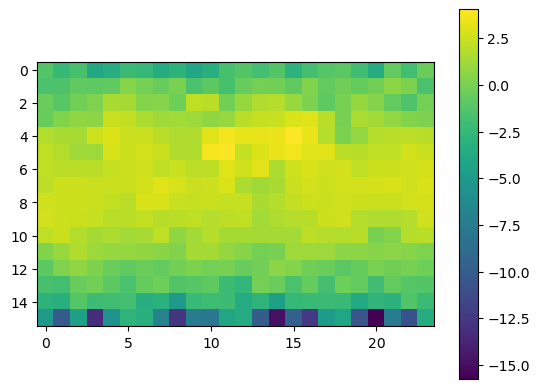

In [29]:
plt.imshow(y_sample[0, 59].cpu().detach().numpy())
plt.colorbar()


In [27]:
input_sample = next(iter(dataloader))
input_sample.shape

torch.Size([128, 128, 16, 24])

In [28]:
len(dataloader)

164

In [29]:
torch.manual_seed(0)
np.random.seed(0)

In [30]:
input_sample.shape

torch.Size([128, 128, 16, 24])

# How Diffusion Works

### Sampling $x_t$ from markov chain
[DDPM Paper](https://arxiv.org/pdf/2006.11239)
Given a **fixed** noise schedule $\{\beta_1, ..., \beta_T\}$, we can define $\alpha_t:= 1- \beta_t$ and $\bar{\alpha_t} = \prod_{s=1}^t \alpha_s$

Giving rules for products of gaussians, we can conveniently sample from any arbitrary node in the Markov Chain as long as we condition on $x_0$. $$q(x_t|x_0) = \mathcal N(\sqrt{\bar{\alpha_t}} \cdot x_0, (1-\bar{\alpha_t}) I)$$

Given a sample $\epsilon$ drawn from a standard gaussian, we leverage this to reparameterize $$x_t(x_0, \epsilon) = \sqrt{\bar{\alpha_t}} \cdot x_0 + \sqrt{1-\bar{\alpha_t}} \cdot \epsilon$$


The loss, which can also be interpreted as training a noise-conditional score based model, is (14) from the paper: $$L_{simple} := \mathbb{E} [||\epsilon - \epsilon_\theta(x_t(x_0, \epsilon, t), t)||^2]$$

In [30]:
train_steps = 100

In [25]:
noise_scheduler  = data.load_scheduler(mconfig)
noise_scheduler

DDPMScheduler {
  "_class_name": "DDPMScheduler",
  "_diffusers_version": "0.32.2",
  "beta_end": 0.02,
  "beta_schedule": "linear",
  "beta_start": 0.0001,
  "clip_sample": false,
  "clip_sample_range": 4.0,
  "dynamic_thresholding_ratio": 0.995,
  "num_train_timesteps": 100,
  "prediction_type": "epsilon",
  "rescale_betas_zero_snr": false,
  "sample_max_value": 1.0,
  "steps_offset": 0,
  "thresholding": false,
  "timestep_spacing": "leading",
  "trained_betas": null,
  "variance_type": "fixed_small"
}

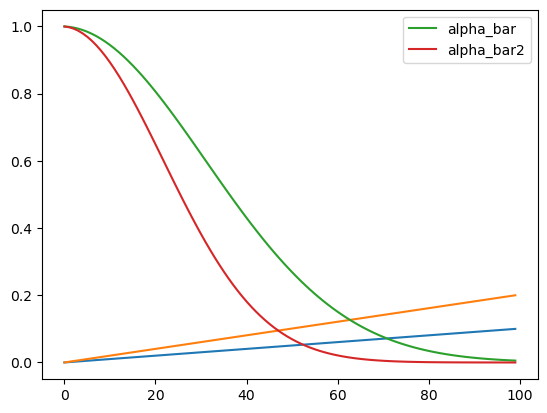

In [37]:

scheduler = diffusers.DDPMScheduler(
    num_train_timesteps=100,
    beta_start=0.0001,
    beta_end=0.1,  # Changed from 0.01 to 0.2
    beta_schedule="linear",
)
scheduler2 = diffusers.DDPMScheduler(
    num_train_timesteps=100,
    beta_start=0.0001,
    beta_end=0.2,  # Changed from 0.01 to 0.2
    beta_schedule="linear",
)
plt.plot(scheduler.betas)
plt.plot(scheduler2.betas)
plt.plot(scheduler.alphas_cumprod, label='alpha_bar')
plt.plot(scheduler2.alphas_cumprod, label='alpha_bar2')
plt.legend()
plt.show()

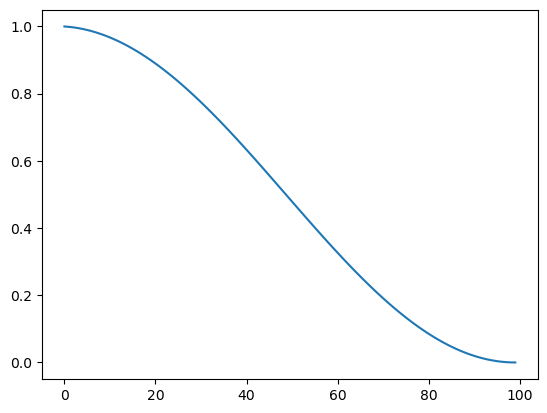

In [34]:
plt.plot(scheduler.alphas_cumprod)

In [26]:
print(noise_scheduler.config.num_train_timesteps)
print(noise_scheduler.timesteps)
noise_scheduler.set_timesteps(10)
noise_scheduler.timesteps

100
tensor([99, 98, 97, 96, 95, 94, 93, 92, 91, 90, 89, 88, 87, 86, 85, 84, 83, 82,
        81, 80, 79, 78, 77, 76, 75, 74, 73, 72, 71, 70, 69, 68, 67, 66, 65, 64,
        63, 62, 61, 60, 59, 58, 57, 56, 55, 54, 53, 52, 51, 50, 49, 48, 47, 46,
        45, 44, 43, 42, 41, 40, 39, 38, 37, 36, 35, 34, 33, 32, 31, 30, 29, 28,
        27, 26, 25, 24, 23, 22, 21, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10,
         9,  8,  7,  6,  5,  4,  3,  2,  1,  0])


tensor([90, 80, 70, 60, 50, 40, 30, 20, 10,  0])

In [28]:
def get_alpha_t_manual(t, scheduler=noise_scheduler):
    a = 1
    for s in range(t+1):
        a = a * (1-scheduler.betas[s])
    return(a)
print(get_alpha_t_manual(5) - noise_scheduler.alphas_cumprod[5])
noise_scheduler.alphas_cumprod[:6]

tensor(0.)


tensor([0.9999, 0.9996, 0.9991, 0.9984, 0.9975, 0.9964])

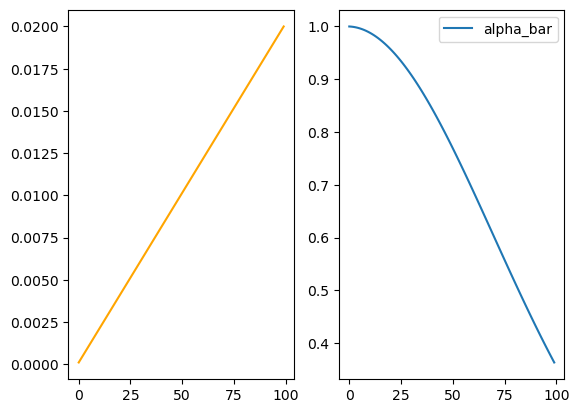

In [29]:
fig, axes = plt.subplots(1, 2, sharex=True)
axes[1].plot(noise_scheduler.alphas_cumprod, label='alpha_bar')
axes[0].plot(noise_scheduler.betas, label='betas', color='orange')
plt.legend()
plt.show()

In [80]:
def sample_xt(x0, t):
    eps = torch.randn(x0.shape) # BS x C x H x W
    xt = noise_scheduler.add_noise(x0, eps, torch.LongTensor(t)) # noisy image
    return(xt, eps)

In [81]:
t = 50

In [82]:
x50, eps = sample_xt(input_sample, [t])

In [83]:
at = noise_scheduler.alphas_cumprod[t]
x50_manual = torch.sqrt(at) * input_sample + torch.sqrt(1-at)*eps

In [84]:
loss_fn = torch.nn.MSELoss()

In [85]:
loss_fn(x50_manual, x50) # the same! 

tensor(0.)

Loss called to match model prediction to actual noise used to generate noisy latent. 

training_loss = loss_fn(model(x_t, t).sample, epsilon_noise_sample)

In [86]:
eps.shape

torch.Size([128, 128, 16, 24])

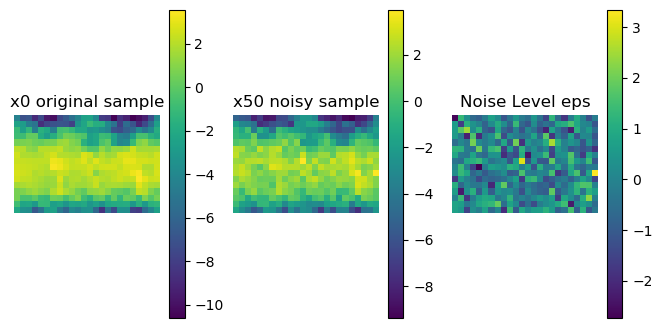

In [87]:
fig, axes = plt.subplots(1, 3, figsize=(8, 4))

im0 = axes[0].imshow(input_sample.permute(0, 2, 3, 1).cpu().numpy()[0, :, :, 59], 'viridis')
axes[0].title.set_text("x0 original sample")
axes[0].set_axis_off()

im1 = axes[1].imshow(x50.permute(0, 2, 3, 1).cpu().numpy()[0, :, :, 59], 'viridis')
axes[1].set_axis_off()
axes[1].title.set_text("x50 noisy sample")

im2 = axes[2].imshow(eps[0, 59, :, :], 'viridis')
axes[2].set_axis_off()
axes[2].title.set_text("Noise Level eps")

fig.colorbar(im0, ax=axes[0], orientation='vertical')
fig.colorbar(im1, ax=axes[1], orientation='vertical')
fig.colorbar(im2, ax=axes[2], orientation='vertical')
plt.show()

In [96]:
x100, eps = sample_xt(input_sample, [99])

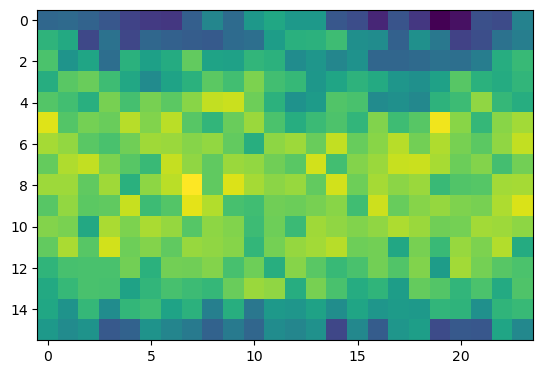

In [98]:
plt.imshow(x100[0, 59])

### testing speed 

In [62]:
class DiffusionDataset(torch.utils.data.Dataset):
    def __init__(self, image_dataset, mconfig):
        self.dataset = image_dataset
        self.scheduler = image_dataset.scheduler
        self.device = image_dataset.device
        self.num_timesteps = self.scheduler.config.num_train_timesteps
        self.sample_shape = image_dataset[0].shape
        self.static_noise = torch.randn(self.sample_shape, device=self.device)
    
    def __len__(self):
        return(len(self.dataset))

    def __getitem__(self, idx, timestep=-1, static=False):
        clean_image = self.dataset[idx]
        noise = self.static_noise if static else torch.randn(clean_image.shape, device=self.device)
        timestep = torch.randint(0, self.num_timesteps, size=(1,), device=self.device, dtype=torch.int64)
        noisy_image = self.scheduler.add_noise(clean_image, noise, timestep)
        return(noisy_image, timestep, noise)

diffds = DiffusionDataset(train_ds, mconfig)
dl = DataLoader(train_ds, batch_size=tconfig.batch_size, shuffle=False)
def custom_cfn(batch):
    noisy_images = torch.stack([item[0] for item in batch])  # Shape [N, C, H, W]
    timesteps = torch.cat([item[1] for item in batch])  # Shape [N]
    noise = torch.stack([item[2] for item in batch])  # Shape [N, C, H, W]
    return noisy_images, timesteps, noise
diffdl = DataLoader(diffds, batch_size=tconfig.batch_size, shuffle=False, collate_fn=custom_cfn)



In [63]:
%%timeit
for step, batch in enumerate(dl):
    noisy_images, timesteps, noise = dl.dataset.noise_batch(batch)

48.3 ms ± 57.5 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [64]:
# definitely slower
%%timeit
for step, batch in enumerate(diffdl):
    noisy_images, timesteps, noise = batch

217 ms ± 3.33 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


### How much Noise Destroys Sample? 

$$ \mathbb{E}[(X+\epsilon)^T (X+\epsilon)] = \mathbb{E}[(X^T X +\epsilon^T \epsilon)]$$
$$ = V \Lambda V^{-1} + V \sigma^2 I V^{-1} = V (\Lambda + \sigma^2 I) V^{-1}$$

In [44]:
print(input_sample.shape)

X = input_sample.reshape(128, -1)
X.shape

torch.Size([128, 128, 16, 24])


torch.Size([128, 49152])

(array([3.147400e+04, 6.166840e+05, 4.765198e+06, 8.762120e+05,
        1.408000e+03, 3.130000e+02, 1.000000e+02, 4.800000e+01,
        1.700000e+01, 2.000000e+00]),
 array([-12.39433002,  -7.5774169 ,  -2.76050377,   2.05640888,
          6.87332249,  11.69023609,  16.50714874,  21.32406235,
         26.14097595,  30.95788956,  35.77480316]),
 <BarContainer object of 10 artists>)

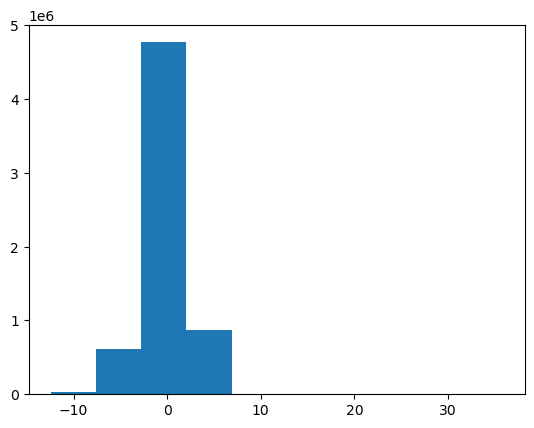

In [74]:
plt.hist(X.flatten())

In [58]:
M = torch.matmul(X, torch.transpose(X, 0, 1)).numpy()
print(f"M symmetric: {np.isclose(M, M.T).all()}")
M.shape

M symmetric: True


(128, 128)

In [59]:
eig, Q = np.linalg.eigh(M)

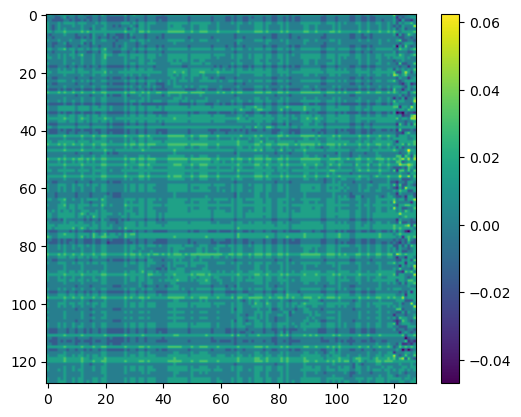

In [69]:
Mhat = np.dot(np.dot(Q, np.diag(eig)), Q.T)

plt.imshow(Mhat - M)
plt.colorbar()

In [101]:
eig[-5:]

array([  146702.64,   304552.34,   419825.9 ,   547966.  , 26701584.  ],
      dtype=float32)

These eigenvalues seem really high...

## How Reverse Diffusion with trained model works

Given $\epsilon$, we can obtain the distribution for a reverse diffusion step. Recall that $$p_\theta(x_{t-1} | x_t) := \mathcal{N}(x_{t-1}; \mu_\theta(x_t, t), \Sigma_\theta=\sigma_t^2 I)$$
where $\sigma_t^2=\beta_t$ is a common choice. 


$$x_{t-1} =\dfrac{1}{\alpha_t}\left(x_t - \dfrac{\beta_t}{\sqrt{1-\alpha_t}} \epsilon_\theta(x_t, t)\right) + \sigma_t z \,\,\,\,\,\, z \sim \mathcal N(0, I)$$

More simply, since $x_t = \sqrt{1 - \beta_t} x_{t-1} + \sqrt{\beta_t} \sigma_t$, then $x_{t-1} = \dfrac{1}{\alpha_t}(x_t - \sqrt{\beta_t} \epsilon_\theta)$

In [68]:
noise_scheduler.timesteps

tensor([99, 98, 97, 96, 95, 94, 93, 92, 91, 90, 89, 88, 87, 86, 85, 84, 83, 82,
        81, 80, 79, 78, 77, 76, 75, 74, 73, 72, 71, 70, 69, 68, 67, 66, 65, 64,
        63, 62, 61, 60, 59, 58, 57, 56, 55, 54, 53, 52, 51, 50, 49, 48, 47, 46,
        45, 44, 43, 42, 41, 40, 39, 38, 37, 36, 35, 34, 33, 32, 31, 30, 29, 28,
        27, 26, 25, 24, 23, 22, 21, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10,
         9,  8,  7,  6,  5,  4,  3,  2,  1,  0])

In [70]:
x50.shape, eps.shape

(torch.Size([4, 128, 16, 24]), torch.Size([4, 128, 16, 24]))

In [78]:
gen = torch.Generator()

In [97]:
x49 = noise_scheduler.step(eps, timestep=50, sample=x50, generator=gen).prev_sample

In [98]:
x49b = noise_scheduler.step(eps, timestep=50, sample=x50, generator=gen).prev_sample

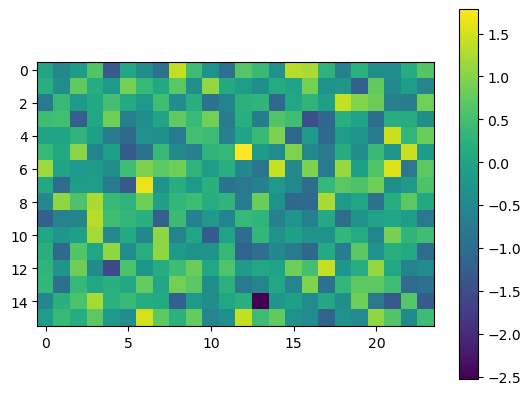

In [103]:
sigma_diff = (x49 - x49b) / np.sqrt(noise_scheduler.betas[50])
plt.imshow(sigma_diff[0,59,:,:]/2)
plt.colorbar()

In [92]:
def manual_inference_step(epsilon, t, xt, scheduler):
    # x t-1
    bt = noise_scheduler.betas[t]
    x = xt - np.sqrt(bt) * epsilon
    x = x / np.sqrt(1 - bt)
    return(x)

In [104]:
def run_pipeline(model, scheduler):
    # get x t-1 given x_t
    input =  torch.randn(input_sample.shape)
    for t in scheduler.timesteps:
        with torch.no_grad():
            noisy_residual = model(input, t).sample
        previous_noisy_sample = scheduler.step(noisy_residual, t, input).prev_sample
        input = previous_noisy_sample


## U Net Model

Ok so we have our noisy dataset and our well defined task. Let's explore the model!

- U Net at its core is a convolution based encoder decoder architecture that progressively reduces height/width dimensionality but adds channels with "down blocks" and rescales with "upblocks". Residual connections as well
- Timestep is fed into noise-conditional model via a time embedding. "temb" is a parameter in all the downsample blocks


Resources: 
- [Time Embeddings and conditioning](https://varun-ml.github.io/posts/diffusion-models/denoising-diffusion-models-2/)

In [43]:
@dataclass
class DiffusionModelConfig:
    model_type: str = "diffusion"
    image_height = 16
    image_width  = 24
    in_channels: int = 128
    latent_dims: int = 16
    out_channels: int = 128
    block_out_channels: Tuple = field(default_factory=lambda: (32, 64, 64, 128))  # num output channel for each UNet block
    down_blocks: Tuple = field(default_factory=lambda: (
        "DownBlock2D",  # a regular ResNet downsampling block
        "DownBlock2D",
        "AttnDownBlock2D",  # a ResNet downsampling block with spatial self-attention
        "DownBlock2D",
    ))
    up_blocks: Tuple = field(default_factory=lambda: (
        "UpBlock2D",  # a regular ResNet upsampling block
        "AttnUpBlock2D",  # a ResNet upsampling block with spatial self-attention
        "UpBlock2D",
        "UpBlock2D",
    ))

In [44]:
def load_model(config, device):
    registered = ['VAE', 'diffusion', 'latent_diffusion']
    match config.model_type:
        case "VAE":
            model = VariationalAutoencoder(
                data_dims= config.num_channels, 
                latent_dims= config.latent_dims, 
                hidden_dims= config.ae_hidden_dims, 
                device = device,
            )
        case model_type if "diffusion" in model_type:
            channels = config.latent_dims if 'latent' in model_type else config.in_channels
            model = diffusers.UNet2DModel(
                sample_size=(config.image_height, config.image_width),  # the target image resolution
                in_channels=channels,  # the number of input channels, 3 for RGB images
                out_channels=channels,  # the number of output channels
                layers_per_block=1,  # how many ResNet layers to use per UNet block
                block_out_channels=config.block_out_channels, 
                down_block_types=config.down_blocks, 
                up_block_types=config.up_blocks,
                norm_num_groups=16, 
            ).to(device)
    return(model)

#### Regular Model (no latent space)

In [45]:
mconfig = DiffusionModelConfig()
mconfig

DiffusionModelConfig(model_type='diffusion', in_channels=128, latent_dims=16, out_channels=128, block_out_channels=(32, 64, 64, 128), down_blocks=('DownBlock2D', 'DownBlock2D', 'AttnDownBlock2D', 'DownBlock2D'), up_blocks=('UpBlock2D', 'AttnUpBlock2D', 'UpBlock2D', 'UpBlock2D'))

In [46]:
model = load_model(mconfig, device)

In [47]:
#print(isinstance(layers[1], diffusers.models.embeddings.Timesteps))
t = torch.tensor([1, 2, 3, 4])

In [50]:
input_sample.device

device(type='cpu')

In [51]:
output = model(input_sample.to(device), timestep=0)
output.sample.shape

torch.Size([128, 128, 16, 24])

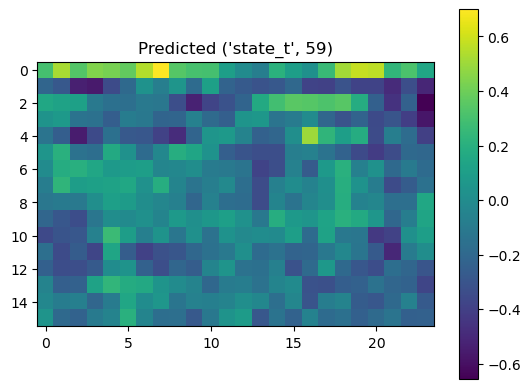

In [52]:
plt.imshow(output.sample[0].cpu().detach().numpy()[59])
plt.title(f"Predicted {train_ds.mlo[59].item()}")
plt.colorbar()
plt.show()

## Latent Diffusion

Following diffusers [source code](https://github.com/huggingface/diffusers/blob/main/src/diffusers/models/unets/unet_2d.py#L243)

In [47]:
class UnconditionalDiffusion(nn.Module):
    def __init__(self, encoder, decoder, unet):
        self.encoder = encoder
        self.decoder = decoder
        self.unet = unet

    def forward(self, noisy_sample):
        noisy_latent = self.encoder(noisy_sample)
        denoised_latent = self.unet(noisy_latent)
        denoised_sample = self.decoder(denoised_latent)

        return(denoised_sample)

In [107]:
lconfig = DiffusionModelConfig()
lconfig.model_type = "latent_diffusion"
lconfig.block_out_channels = (32, 64)
lconfig.down_blocks = ("DownBlock2D", "DownBlock2D")
lconfig.up_blocks = ("UpBlock2D", "UpBlock2D")

In [108]:
ldm = load_model(lconfig, device)

In [194]:
input_sample = torch.randn(4, 16, 16, 24)
ts = [5, 8, 2, 6]

#### How the time embeddings work: 

In [127]:
def time_embed_fwd(self,
    sample: torch.Tensor,
    timestep: Union[torch.Tensor, float, int],
    class_labels: Optional[torch.Tensor] = None,
    ) -> Tuple:
    timesteps = timestep
    if not torch.is_tensor(timesteps):
        timesteps = torch.tensor([timesteps], dtype=torch.long, device=sample.device)
    elif torch.is_tensor(timesteps) and len(timesteps.shape) == 0:
        timesteps = timesteps[None].to(sample.device)

    # broadcast to batch dimension in a way that's compatible with ONNX/Core ML
    timesteps = timesteps * torch.ones(sample.shape[0], dtype=timesteps.dtype, device=timesteps.device)
    t_emb = self.time_proj(timesteps)

    # timesteps does not contain any weights and will always return f32 tensors
    # but time_embedding might actually be running in fp16. so we need to cast here.
    # there might be better ways to encapsulate this.
    t_emb = t_emb.to(dtype=self.dtype)
    emb = self.time_embedding(t_emb)
    
    if self.class_embedding is not None:
        if class_labels is None:
            raise ValueError("class_labels should be provided when doing class conditioning")

        if self.config.class_embed_type == "timestep":
            class_labels = self.time_proj(class_labels)
        class_emb = self.class_embedding(class_labels).to(dtype=self.dtype)
        emb = emb + class_emb
    elif self.class_embedding is None and class_labels is not None:
        raise ValueError("class_embedding needs to be initialized in order to use class conditioning")
    return(timesteps, t_emb, emb)

[source code](https://github.com/huggingface/diffusers/blob/main/src/diffusers/models/embeddings.py)

1. First the timesteps are processed to ensure that they match the batch size, meaning we have N proper copies of model(x_t, t).
2. The Timesteps class calls get_timestep_embedding which creates sinusoidal embeddings (something something sin-cos of $e^{f(t)}$). For each timestep, creates a 32 dimensional positional embedding
3. From these 32 dim time_embedding vectors, the model's TimestepEmbedding is a learned nn.Module that further projects the embedding into a final 128 dimensional embedding. Presumably this is a learned projection.

Eventually, these conditioned embeddings are fit into our blocks

In [128]:
type(ldm.time_proj), type(ldm.time_embedding)

(diffusers.models.embeddings.Timesteps,
 diffusers.models.embeddings.TimestepEmbedding)

In [129]:
ldm.time_embedding

TimestepEmbedding(
  (linear_1): Linear(in_features=32, out_features=128, bias=True)
  (act): SiLU()
  (linear_2): Linear(in_features=128, out_features=128, bias=True)
)

In [130]:
timesteps, temb, emb = time_embed_fwd(ldm, sample, timestep=torch.tensor(ts))

In [131]:
temb.shape, emb.shape # both are torch tensors

(torch.Size([4, 32]), torch.Size([4, 128]))

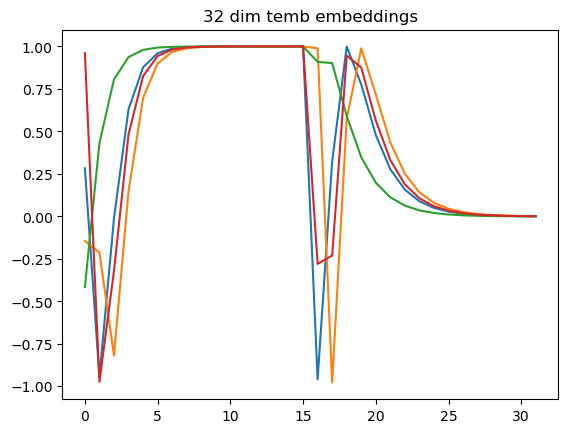

In [132]:
for i in range(4):
    plt.plot(temb[i])
plt.title("32 dim temb embeddings")
plt.show()

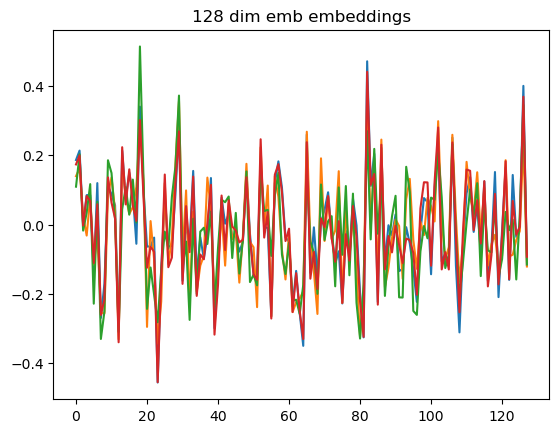

In [133]:
emb = emb.detach().numpy()
for i in range(4):
    plt.plot(emb[i])

plt.title("128 dim emb embeddings")
plt.show()

In [134]:
ldm.time_proj

Timesteps()

#### How the down blocks work

In [160]:
timesteps, temb, emb = time_embed_fwd(ldm, sample, timestep=torch.tensor(ts))

In [161]:
skip_sample = input_sample
sample = ldm.conv_in(input_sample)

skip_sample.shape, sample.shape

(torch.Size([4, 16, 16, 24]), torch.Size([4, 32, 16, 24]))

In [162]:
def down_blocks_fwd(self, sample: torch.Tensor, emb, skip_sample, ) -> Tuple:
    down_block_res_samples = (sample,)
    for downsample_block in self.down_blocks:
        if hasattr(downsample_block, "skip_conv"):
            sample, res_samples, skip_sample = downsample_block(
                hidden_states=sample, temb=emb, skip_sample=skip_sample
            )
        else:
            sample, res_samples = downsample_block(hidden_states=sample, temb=emb)

        down_block_res_samples += res_samples
    return(sample, res_samples, skip_sample, down_block_res_samples)
    

In [163]:
(1,) + (2,) # tuple addition is concat; down_block_res_samples stores all res blocks

(1, 2)

In [164]:
sample, res_samples, skip_sample, down_block_res_samples = down_blocks_fwd(ldm, sample, emb, skip_sample)

In [176]:
sample.shape, len(res_samples), res_samples[0].shape, skip_sample.shape, 

(torch.Size([4, 64, 8, 12]),
 1,
 torch.Size([4, 64, 8, 12]),
 torch.Size([4, 16, 16, 24]))

In [177]:
for i in down_block_res_samples:
    print(i.shape)


torch.Size([4, 32, 16, 24])
torch.Size([4, 32, 16, 24])
torch.Size([4, 32, 8, 12])
torch.Size([4, 64, 8, 12])


In [168]:
lconfig.block_out_channels

(32, 64)

- conv_in goes from in_channels to block[0]
- first downblock is block[0] to block[0]
- then each one is $i-1 \rightarrow i$ for i in range(1, len(block)-1)
Then, for 

In [187]:
ldm.conv_in(input_sample).shape

torch.Size([4, 32, 16, 24])

In [188]:
sample, resid = ldm.down_blocks[0](ldm.conv_in(input_sample), emb, input_sample)

In [191]:
resid[0].shape, resid[1].shape

(torch.Size([4, 32, 16, 24]), torch.Size([4, 32, 8, 12]))

### How the up blocks work

In [199]:
def up_blocks_fwd(self, sample: torch.Tensor, emb, down_block_res_samples) -> Tuple:
    skip_sample = None
    for upsample_block in self.up_blocks:
        res_samples = down_block_res_samples[-len(upsample_block.resnets) :]
        down_block_res_samples = down_block_res_samples[: -len(upsample_block.resnets)]

        if hasattr(upsample_block, "skip_conv"):
            sample, skip_sample = upsample_block(sample, res_samples, emb, skip_sample)
        else:
            sample = upsample_block(sample, res_samples, emb)
    return(sample, skip_sample)

### All together

In [53]:
def forward(self,
    sample: torch.Tensor,
    timestep: Union[torch.Tensor, float, int],
    class_labels: Optional[torch.Tensor] = None,
    ):
    r"""
    The [`UNet2DModel`] forward method.

    Args:
        sample (`torch.Tensor`):
            The noisy input tensor with the following shape `(batch, channel, height, width)`.
        timestep (`torch.Tensor` or `float` or `int`): The number of timesteps to denoise an input.
        class_labels (`torch.Tensor`, *optional*, defaults to `None`):
            Optional class labels for conditioning. Their embeddings will be summed with the timestep embeddings.
        return_dict (`bool`, *optional*, defaults to `True`):
            Whether or not to return a [`~models.unets.unet_2d.UNet2DOutput`] instead of a plain tuple.

    Returns:
        [`~models.unets.unet_2d.UNet2DOutput`] or `tuple`:
            If `return_dict` is True, an [`~models.unets.unet_2d.UNet2DOutput`] is returned, otherwise a `tuple` is
            returned where the first element is the sample tensor.
    """
    # 0. center input if necessary
    if self.config.center_input_sample:
        sample = 2 * sample - 1.0

    # 1. time
    timesteps, t_emb, emb = time_embed_fwd(self, sample, timestep, class_labels)
    # 2. pre-process
    skip_sample = sample
    sample = self.conv_in(sample)

    # 3. down
    sample, res_samples, skip_sample, down_block_res_samples = down_blocks_fwd(self, sample, emb, skip_sample, )

    # 4. mid
    sample = self.mid_block(sample, emb)

    # 5. up
    sample, skip_sample = up_blocks_fwd(self, sample, emb, down_block_res_samples)

    # 6. post-process
    sample = self.conv_norm_out(sample)
    sample = self.conv_act(sample)
    sample = self.conv_out(sample)

    if skip_sample is not None:
        sample += skip_sample

    if self.config.time_embedding_type == "fourier":
        timesteps = timesteps.reshape((sample.shape[0], *([1] * len(sample.shape[1:]))))
        sample = sample / timesteps

    return (sample)

In [54]:
input_sample = torch.randn(4, 16, 16, 24)
ts = [5, 8, 2, 6]

In [55]:
output = forward(ldm, input_sample, torch.tensor(ts))

NameError: name 'ldm' is not defined

In [204]:
ldm_output = ldm(input_sample, torch.tensor(ts))

In [205]:
(output == ldm_output.sample).all()

tensor(True)

In [206]:
output.shape

torch.Size([4, 16, 16, 24])

## Injecting Conditioning Signals

# Actual Training

Helpful links on training troubleshooting:
- [underfitting](https://stats.stackexchange.com/questions/352036/what-should-i-do-when-my-neural-network-doesnt-learn)
- [Unit testing ML](https://thenerdstation.medium.com/how-to-unit-test-machine-learning-code-57cf6fd81765)